In [18]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [19]:
df = sns.load_dataset("titanic")

Feature = ["pclass","sex","fare", "embarked","age"]
target = ["survived"]

from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])
imp_freq = SimpleImputer(strategy="most_frequent")

df[["embarked"]] = imp_freq.fit_transform(df[["embarked"]])

In [20]:
EC = LabelEncoder()

df["sex"] = EC.fit_transform(df["sex"])
df["embarked"]= EC.fit_transform(df["embarked"])

X = df[Feature]
y = df[target]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, random_state=42 , test_size=0.2
)

Model = DecisionTreeClassifier()
Model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_testing_pred = Model.predict(X_test)
y_training_pred = Model.predict(X_train)

print("Trainig accuarcy_score :",accuracy_score(y_train,y_training_pred),"%")
print("testing accuracy_score :", accuracy_score(y_test,y_testing_pred),"%")

Trainig accuarcy_score : 0.9775280898876404 %
testing accuracy_score : 0.7877094972067039 %


# Classic Case of overfitting 

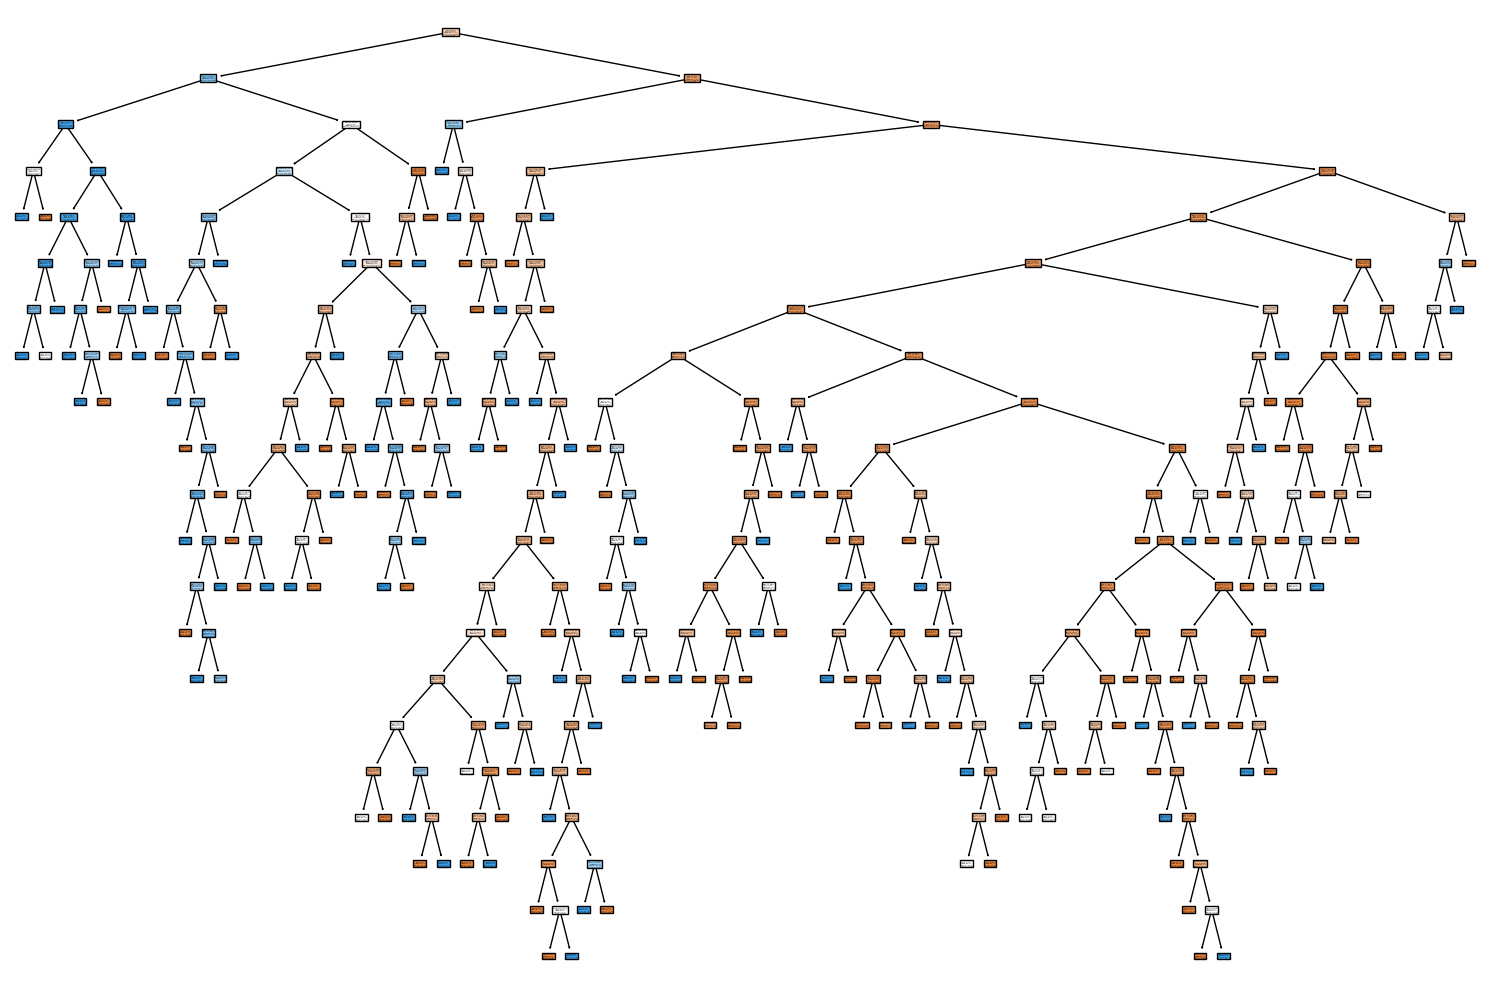

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(
    Model,
    feature_names=X.columns,
    class_names=["died","Alive"],
    filled= True 
)

plt.tight_layout()

In [27]:
# Random foreset classifier 
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(
    n_estimators=  501 ,  # no of models  for classifiication we take these odd 
    oob_score=True,
    bootstrap= True,
    random_state= 42 
)

RF.fit(X_train, y_train.values.ravel())


,n_estimators,501
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [28]:
y_pred = RF.predict(X_test)

print("Out of Bag score :", RF.oob_score_)
print("testing accuracy_score :", accuracy_score(y_test, y_pred), "%")

Out of Bag score : 0.8033707865168539
testing accuracy_score : 0.8044692737430168 %
